# README


**Project Title: Electric Vehicle Population**  

**Tutorial section: TT5L**

**Group_04**

<div align="left">
    
| | Student ID     | Student Name                | Contribution | 
|--:|:-------------|:----------------------------|-------------:|
| 1 | 243UC247CL  | SURAJ A/L PRAKASH           | 25%          | 
| 2 | 243UC247BZ  | LIM JIAN FENG          | 25%          | 
| 3 | 251UC250MH | WONG PEI JUAN             | 25%          | 
| 4 | 251UC250N4  | SONIYASREE A/P VEERAPATHIRAN               | 25%          | 

</div>

Note: Marks may vary among group members based on individual contributions. Ensure all members agree on the contribution percentages listed here.

**YouTube link:**  
Please note that the examiner will not notify you if your video link is unavailable, inaccessible, or incorrectly provided. It is the responsibility of the group to ensure that the video link is fully functional and accessible at the time of assessment. Failure to provide a valid and working link will result in a score of zero (0) marks for the presentation component.

**Dataset Title:**  
**Source & Link:** (e.g., Kaggle / UCI / Data.gov / Google Dataset Search — provide the dataset page URL)  
**Download instructions:** If the dataset requires sign-in (e.g., Kaggle), document the exact steps here      
**Brief Description (2–4 sentences):**   

**How to Run (if required, 1–3 steps):**  
  Instructions to run the notebook, including how to place the dataset files.    
  

## 1. Introduction & Problem Statement
- What is the main objective of this analysis?
- What key questions/hypotheses will you explore?
- Why is this dataset suitable for these questions?
- All citations must be in listed in APA style.


## 2. Data Source & Understanding

**Dataset Title:** Electric Vehicle Population Data  
**Source:** IDK  
**Last Updated:** Check source page for latest version  

**Description:**  
This dataset contains Battery Electric Vehicles (BEVs) and Plug-in Hybrid Electric Vehicles (PHEVs) currently registered through the Washington State DOL. Each row represents one registered vehicle and includes information on make, model, model year, electric range, vehicle type, CAFV eligibility, and geographic details (county, city, postal code).

- **Size:** ~135,000 rows × 17 columns (as of this snapshot)  
- **Time span:** Model years 1997–2024  
- **Key numeric columns:** `Model Year`, `Electric Range`, `Base MSRP`, `Legislative District`, `2020 Census Tract`  
- **Key categorical columns:** `Make`, `Model`, `Electric Vehicle Type`, `CAFV Eligibility`, `County`, `City`, `State`  

**Limitations:**  
- Coverage is limited to Washington State; findings may not generalise to other states or countries.  
- `Electric Range` is frequently 0 (reported as missing/unknown for PHEVs) — a significant source of missingness.  
- `Base MSRP` is largely missing and will be excluded from analysis.  
- The dataset reflects *registered* vehicles only, not sales figures or total adoption rates.  
- Geographic fields (`Vehicle Location`, `2020 Census Tract`) are incomplete for some records.


In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Consistent plot styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110


In [2]:
# Load data (single load — do not reload elsewhere in notebook)
file_path = "Electric_Vehicle_Population_Data.csv"
ev_data = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print(f"Shape: {ev_data.shape[0]:,} rows × {ev_data.shape[1]} columns")


Dataset loaded successfully.
Shape: 135,038 rows × 17 columns


## 3. Initial Data Checks

Before any cleaning, we inspect the raw data to understand its structure, spot obvious issues, and record a baseline for later comparison.


In [3]:
# 3.1 Column names & data types
print("COLUMNS & DATA TYPES \n")
print(ev_data.dtypes.to_string())


COLUMNS & DATA TYPES 

VIN (1-10)                                            object
County                                                object
City                                                  object
State                                                 object
Postal Code                                          float64
Model Year                                             int64
Make                                                  object
Model                                                 object
Electric Vehicle Type                                 object
Clean Alternative Fuel Vehicle (CAFV) Eligibility     object
Electric Range                                       float64
Base MSRP                                            float64
Legislative District                                 float64
DOL Vehicle ID                                         int64
Vehicle Location                                      object
Electric Utility                                      object
2

In [4]:
# 3.2 First and last 5 rows
print("First 5 rows:")
display(ev_data.head())

print("\nLast 5 rows:")
display(ev_data.tail())


First 5 rows:


,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,5YJ3E1EA0K,Thurston,Tumwater,WA,98512.0,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,0.0,22.0,242565116,POINT (-122.91310169999997 47.01359260000004),PUGET SOUND ENERGY INC,5.306701e+10
1,1N4BZ1DV4N,Island,Clinton,WA,98236.0,2022,NISSAN,LEAF,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,0.0,10.0,183272785,POINT (-122.35936399999997 47.97965520000008),PUGET SOUND ENERGY INC,5.302997e+10
2,5YJ3E1EA0L,Snohomish,Snohomish,WA,98290.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,266.0,0.0,44.0,112552366,POINT (-122.09150499999998 47.91555500000004),PUGET SOUND ENERGY INC,5.306105e+10
3,5YJ3E1EBXL,King,Seattle,WA,98134.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,322.0,0.0,11.0,6336319,POINT (-122.32981499999994 47.579810000000066),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
4,5YJSA1CP0D,Snohomish,Edmonds,WA,98020.0,2013,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,208.0,69900.0,21.0,186212960,POINT (-122.37507 47.80807000000004),PUGET SOUND ENERGY INC,5.306105e+10



Last 5 rows:


,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
135033,5YJSA1E29L,King,Yarrow Point,WA,98004.0,2020,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,330.0,0.0,48.0,124776627,POINT (-122.20190499999995 47.61385000000007),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10
135034,5YJYGDEE7M,King,Burien,WA,98168.0,2021,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,0.0,33.0,142857676,POINT (-122.28645999999998 47.47613000000007),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303303e+10
135035,5YJSA1E51N,Pierce,Gig Harbor,WA,98335.0,2022,TESLA,MODEL S,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,0.0,26.0,220157724,POINT (-122.58354539999999 47.32344880000005),BONNEVILLE POWER ADMINISTRATION||CITY OF TACOM...,5.305307e+10
135036,KM8KMDAF3P,Grant,Ephrata,WA,98823.0,2023,HYUNDAI,IONIQ 5,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,0.0,13.0,223872596,POINT (-119.55512999999996 47.319360000000074),PUD NO 2 OF GRANT COUNTY,5.302501e+10
135037,1FADP5CU4E,Kitsap,Port Orchard,WA,98366.0,2014,FORD,C-MAX,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,19.0,0.0,26.0,171102032,POINT (-122.63926499999997 47.53730000000007),PUGET SOUND ENERGY INC,5.303509e+10


In [5]:
# 3.3 Model Year range
print(f"Model Year range: {ev_data['Model Year'].min()} – {ev_data['Model Year'].max()}")


Model Year range: 1997 – 2024


In [6]:
# 3.4 Summary statistics
print("Numeric columns:")
display(ev_data.describe())

Numeric columns:


,Postal Code,Model Year,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,2020 Census Tract
count,135030.000000,135038.000000,135037.000000,135037.000000,134726.000000,1.350380e+05,1.350300e+05
mean,98171.001577,2019.662880,74.591964,1448.407325,29.504379,2.063432e+08,5.297233e+10
std,2450.367211,3.001676,98.744120,9683.658138,14.783780,8.582417e+07,1.635783e+09
min,1730.000000,1997.000000,0.000000,0.000000,1.000000,4.385000e+03,1.081042e+09
25%,98052.000000,2018.000000,0.000000,0.000000,18.000000,1.606305e+08,5.303301e+10
50%,98121.000000,2021.000000,21.000000,0.000000,34.000000,2.059563e+08,5.303303e+10
75%,98370.000000,2022.000000,150.000000,0.000000,43.000000,2.308888e+08,5.305307e+10
max,99701.000000,2024.000000,337.000000,845000.000000,49.000000,4.792548e+08,5.603300e+10


In [7]:
print("\nCategorical columns:")
display(ev_data.describe(include='object'))



Categorical columns:


,VIN (1-10),County,City,State,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Vehicle Location,Electric Utility
count,135038,135030,135030,135038,135038,134789,135038,135038,135028,135030
unique,9059,169,651,46,36,125,2,3,785,76
top,5YJYGDEE9M,King,Seattle,WA,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,POINT (-122.12301999999994 47.67668000000003),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA)
freq,473,70842,23489,134726,61808,25837,103882,61221,3482,49369


In [8]:
#  3.5 Missing values (RAW — before any cleaning)
missing = ev_data.isnull().sum()
missing_pct = (missing / len(ev_data) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)': missing_pct
}).sort_values('Missing (%)', ascending=False)

print("Missing values in raw data:")
display(missing_df)


Missing values in raw data:


,Missing Count,Missing (%)
Legislative District,312,0.23
Model,249,0.18
2020 Census Tract,8,0.01
City,8,0.01
Electric Utility,8,0.01
Postal Code,8,0.01
Vehicle Location,10,0.01
County,8,0.01
Base MSRP,1,0.00
DOL Vehicle ID,0,0.00


In [9]:
# 3.6 Duplicate rows
n_dupes = ev_data.duplicated().sum()
print(f"Duplicate rows: {n_dupes:,}")
if n_dupes == 0:
    print("No duplicates found — no action needed.")


Duplicate rows: 0
No duplicates found — no action needed.


## 4. Data Cleaning & Preprocessing

**Strategy summary:**

| Issue | Column(s) | Action | Justification |
|---|---|---|---|
| 0 treated as missing | `Electric Range` | Replace 0 → NaN | 0 miles is physically meaningless for a registered EV |
| Missing text fields | `Model`, `City`, `County`, `Vehicle Location`, `Electric Utility` | Fill → `"Unknown"` | Preserves row count; rows still usable for Q1 and Q3 |
| Missing CAFV field | `CAFV Eligibility` | Drop rows | Target variable for Q3 — rows with missing target cannot be used |
| Missing `Legislative District` | `Legislative District` | Drop rows | Target variable for Q1 — rows with missing target cannot be used |
| Irrelevant column | `Base MSRP` | Drop column | Mostly 0 or missing; not used in any analytical question |
| Fix types | `Model Year`, `Electric Range`, `Legislative District` | Cast to numeric | Ensures correct computation in regression and clustering |
| Feature engineering | `Electric Range` | Bin into `Range Category` | Enables grouped categorical analysis in EDA |

**Note on row dropping strategy:**  
Rather than one global `dropna`, we keep the base cleaned dataset (`ev_data_clean`) intact and create **question-specific dataframes** where needed. This avoids discarding rows that are valid for some questions but not others.


In [10]:
# 4.1 Replace 0 → NaN in Electric Range
# 0 miles is not a valid range value — it indicates missing/unreported data (common for PHEVs)
print(f"Rows with Electric Range = 0 (before): {(ev_data['Electric Range'] == 0).sum():,}")

ev_data['Electric Range'] = ev_data['Electric Range'].replace(0, np.nan)

print(f"Electric Range NaN (after 0→NaN):      {ev_data['Electric Range'].isna().sum():,}")


Rows with Electric Range = 0 (before): 56,983
Electric Range NaN (after 0→NaN):      56,984


In [11]:
# 4.2 Drop Base MSRP
# Mostly 0 or missing; not used in any of the four analytical questions
print(f"Base MSRP — zero or missing values: {((ev_data['Base MSRP'] == 0) | ev_data['Base MSRP'].isna()).sum():,} / {len(ev_data):,} rows")

ev_data_clean = ev_data.drop(columns=['Base MSRP']).copy()
print("Column 'Base MSRP' dropped.")


Base MSRP — zero or missing values: 131,613 / 135,038 rows
Column 'Base MSRP' dropped.


In [12]:
# 4.3 Fill missing text / geographic fields
# Filling with 'Unknown' preserves row count for Q1 and Q3 which use these as features
fill_unknown = ['Model', 'Vehicle Location', 'County', 'City', 'Electric Utility']
for col in fill_unknown:
    if col in ev_data_clean.columns:
        n = ev_data_clean[col].isna().sum()
        ev_data_clean[col] = ev_data_clean[col].fillna('Unknown')
        if n > 0:
            print(f"  {col}: {n:,} NaN → 'Unknown'")

# Postal Code and 2020 Census Tract — not used in any question
for col in ['Postal Code', '2020 Census Tract']:
    if col in ev_data_clean.columns:
        n = ev_data_clean[col].isna().sum()
        ev_data_clean[col] = ev_data_clean[col].fillna('Unknown')
        if n > 0:
            print(f"  {col}: {n:,} NaN → 'Unknown'")


  Model: 249 NaN → 'Unknown'
  Vehicle Location: 10 NaN → 'Unknown'
  County: 8 NaN → 'Unknown'
  City: 8 NaN → 'Unknown'
  Electric Utility: 8 NaN → 'Unknown'
  Postal Code: 8 NaN → 'Unknown'
  2020 Census Tract: 8 NaN → 'Unknown'


In [13]:
# 4.4 Fix data types
ev_data_clean['Model Year'] = pd.to_numeric(ev_data_clean['Model Year'], errors='coerce')
ev_data_clean['Electric Range'] = pd.to_numeric(ev_data_clean['Electric Range'], errors='coerce')
ev_data_clean['Legislative District'] = pd.to_numeric(ev_data_clean['Legislative District'], errors='coerce')

print("Type conversion complete.")
print(f"  Model Year dtype          : {ev_data_clean['Model Year'].dtype}")
print(f"  Electric Range dtype      : {ev_data_clean['Electric Range'].dtype}")
print(f"  Legislative District dtype: {ev_data_clean['Legislative District'].dtype}")


Type conversion complete.
  Model Year dtype          : int64
  Electric Range dtype      : float64
  Legislative District dtype: float64


In [14]:
# 4.5 Feature engineering: Range Category (for EDA)
ev_data_clean['Range Category'] = pd.cut(
    ev_data_clean['Electric Range'],
    bins=[0, 50, 150, 300, np.inf],
    labels=['Low (<50 mi)', 'Medium (50–150 mi)', 'High (150–300 mi)', 'Very High (>300 mi)'],
    right=False
)

print("Range Category distribution:")
print(ev_data_clean['Range Category'].value_counts().sort_index())


Range Category distribution:
Range Category
Low (<50 mi)           27359
Medium (50–150 mi)     16168
High (150–300 mi)      31906
Very High (>300 mi)     2621
Name: count, dtype: int64


In [15]:
# 4.6 Create question-specific dataframes 

# Q1 — Regression
# Drop rows where target (Legislative District) is missing
df_q1 = ev_data_clean.dropna(subset=['Legislative District']).copy()
print(f"Q1 Regression df   : {df_q1.shape[0]:,} rows  (dropped {len(ev_data_clean) - len(df_q1):,} rows with missing Legislative District)")

# Q2 — Clustering
# Drop rows where Electric Range is missing (core clustering feature)
df_q2 = ev_data_clean.dropna(subset=['Electric Range']).copy()
print(f"Q2 Clustering df   : {df_q2.shape[0]:,} rows  (dropped {len(ev_data_clean) - len(df_q2):,} rows with missing Electric Range)")

# Q3 — Classification
# Drop rows where target (CAFV Eligibility) is missing
cafv_col = 'Clean Alternative Fuel Vehicle (CAFV) Eligibility'
df_q3 = ev_data_clean.dropna(subset=[cafv_col]).copy()
print(f"Q3 Classification df: {df_q3.shape[0]:,} rows  (dropped {len(ev_data_clean) - len(df_q3):,} rows with missing CAFV Eligibility)")

print(f"\nBase cleaned dataset (ev_data_clean): {ev_data_clean.shape[0]:,} rows — used for EDA")


Q1 Regression df   : 134,726 rows  (dropped 312 rows with missing Legislative District)
Q2 Clustering df   : 78,054 rows  (dropped 56,984 rows with missing Electric Range)
Q3 Classification df: 135,038 rows  (dropped 0 rows with missing CAFV Eligibility)

Base cleaned dataset (ev_data_clean): 135,038 rows — used for EDA


In [16]:
# ── 4.7 Verify — missing values in base cleaned dataset ──────────────────────
remaining = ev_data_clean.isnull().sum()
remaining = remaining[remaining > 0]

print("Remaining NaN in ev_data_clean (expected: Electric Range, Legislative District, CAFV):")
print(remaining)
print(f"\nFinal base shape: {ev_data_clean.shape[0]:,} rows × {ev_data_clean.shape[1]} columns")


Remaining NaN in ev_data_clean (expected: Electric Range, Legislative District, CAFV):
Electric Range          56984
Legislative District      312
Range Category          56984
dtype: int64

Final base shape: 135,038 rows × 17 columns


In [17]:
# Display column names as a list
print(ev_data_clean.columns.tolist())

['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year', 'Make', 'Model', 'Electric Vehicle Type', 'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range', 'Legislative District', 'DOL Vehicle ID', 'Vehicle Location', 'Electric Utility', '2020 Census Tract', 'Range Category']


## 5. Exploratory Data Analysis (EDA)
- Univariate distributions
- Bivariate relationships
- Correlations/associations
- Well-labeled, readable plots with units where applicable


### EV Type Distribution

This analysis visualizes the distribution of different electric vehicle (EV) types in the dataset. It helps identify whether Battery Electric Vehicles (BEVs) or Plug-in Hybrid Electric Vehicles (PHEVs) are more commonly registered.

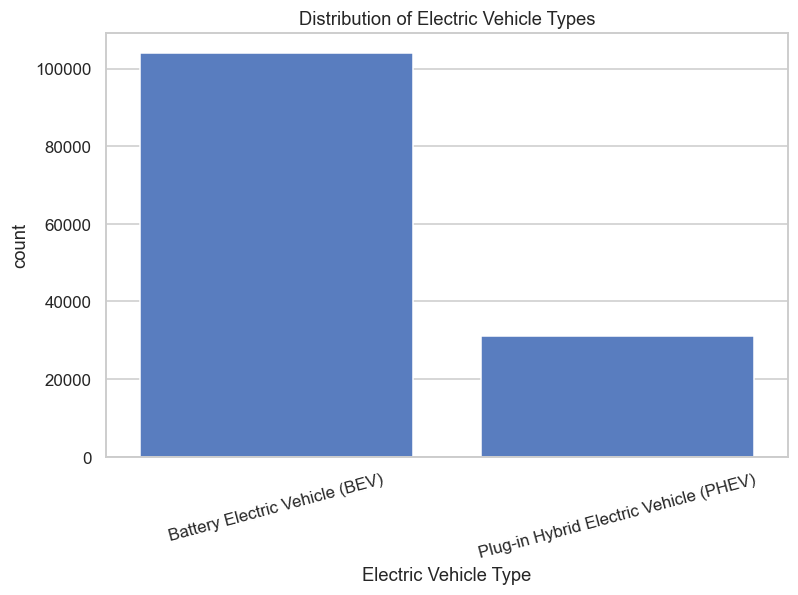

In [18]:
plt.figure(figsize=(8,5))
sns.countplot(data=ev_data_clean, x='Electric Vehicle Type')
plt.xticks(rotation=15)
plt.title('Distribution of Electric Vehicle Types')
plt.show()

### Top Vehicle Makes

This chart displays the top 10 vehicle manufacturers with the highest number of EV registrations. It helps identify the most dominant EV brands in the market.

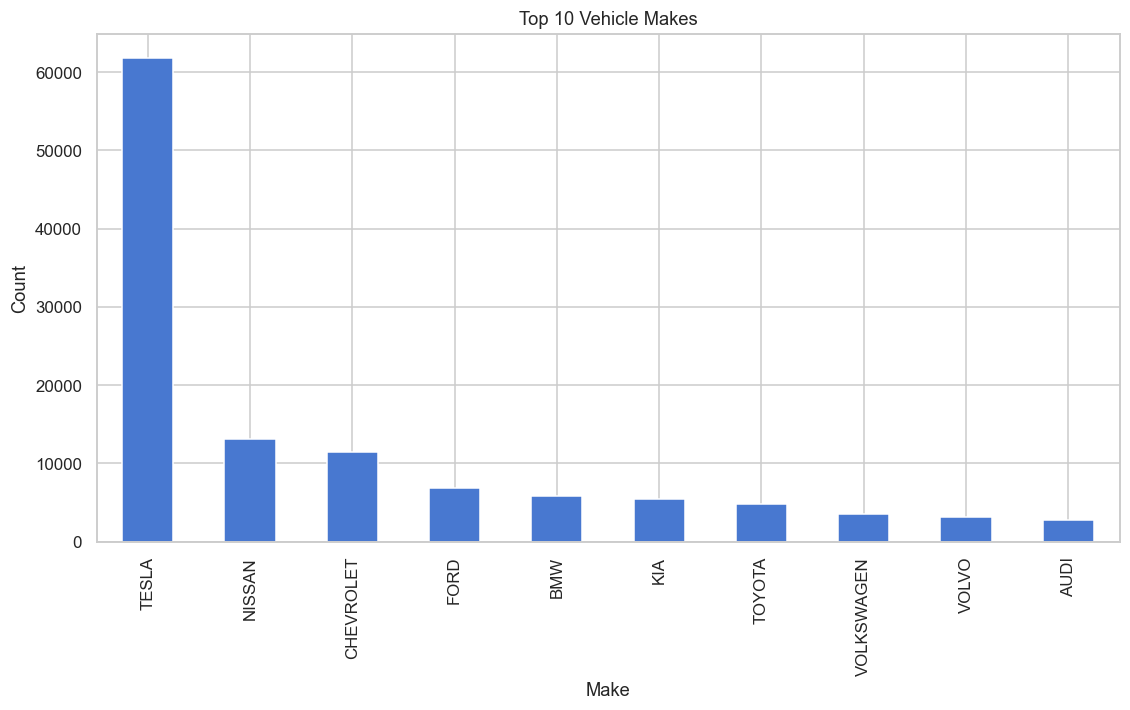

In [19]:
plt.figure(figsize=(12,6))
ev_data_clean['Make'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Vehicle Makes')
plt.xlabel('Make')
plt.ylabel('Count')
plt.show()

### Model Year Distribution

This histogram shows the distribution of EV model years. It helps analyze trends in EV adoption and determine whether registrations are increasing for newer vehicle models.

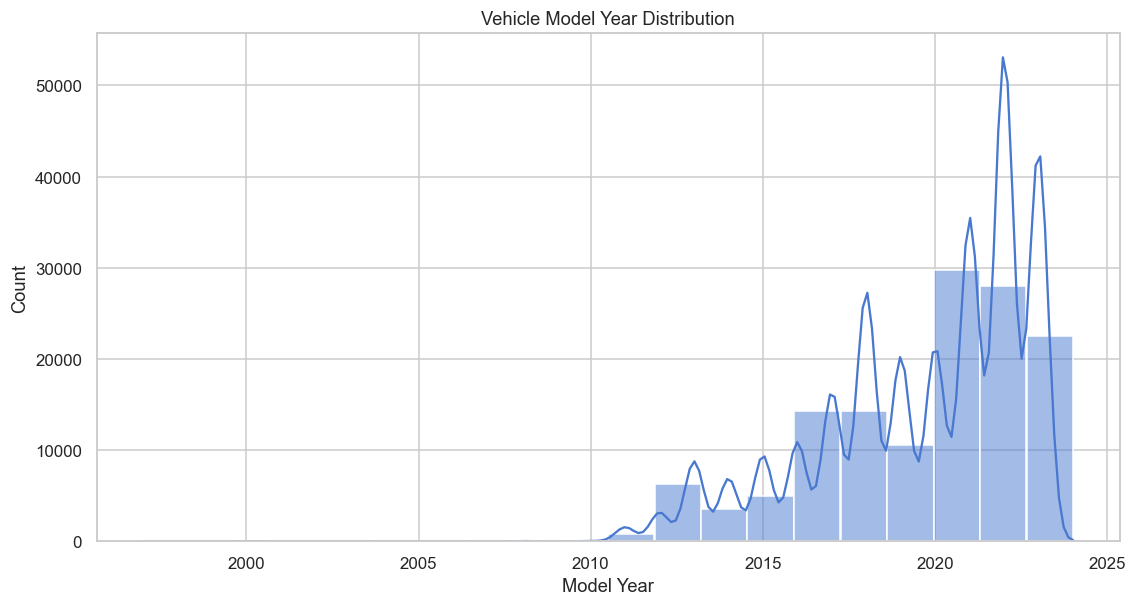

In [20]:
plt.figure(figsize=(12,6))
sns.histplot(ev_data_clean['Model Year'], bins=20, kde=True)
plt.title('Vehicle Model Year Distribution')
plt.show()

### Electric Range by EV Type

This boxplot compares the electric driving range between different EV types. It helps observe differences in performance and identify possible outliers in electric range values.

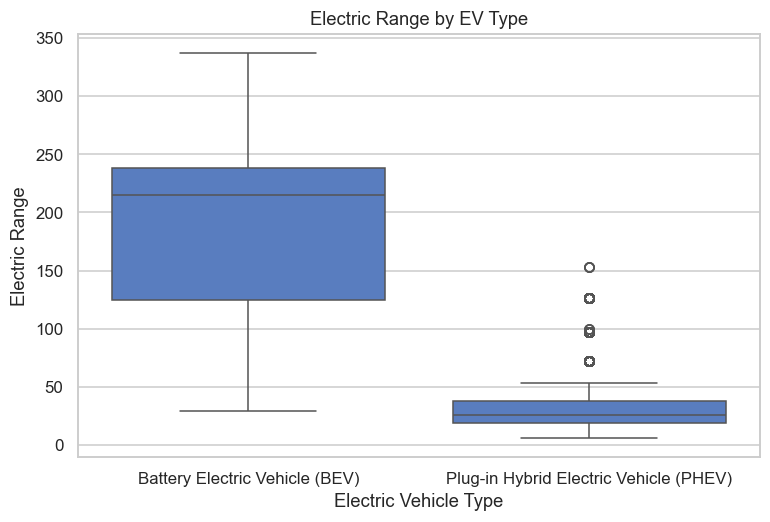

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(data=ev_data_clean, x='Electric Vehicle Type', y='Electric Range')
plt.title('Electric Range by EV Type')
plt.show()

### Top Cities with EV Registrations

This visualization highlights the cities with the highest EV registrations. It provides insight into geographic areas with stronger EV adoption.

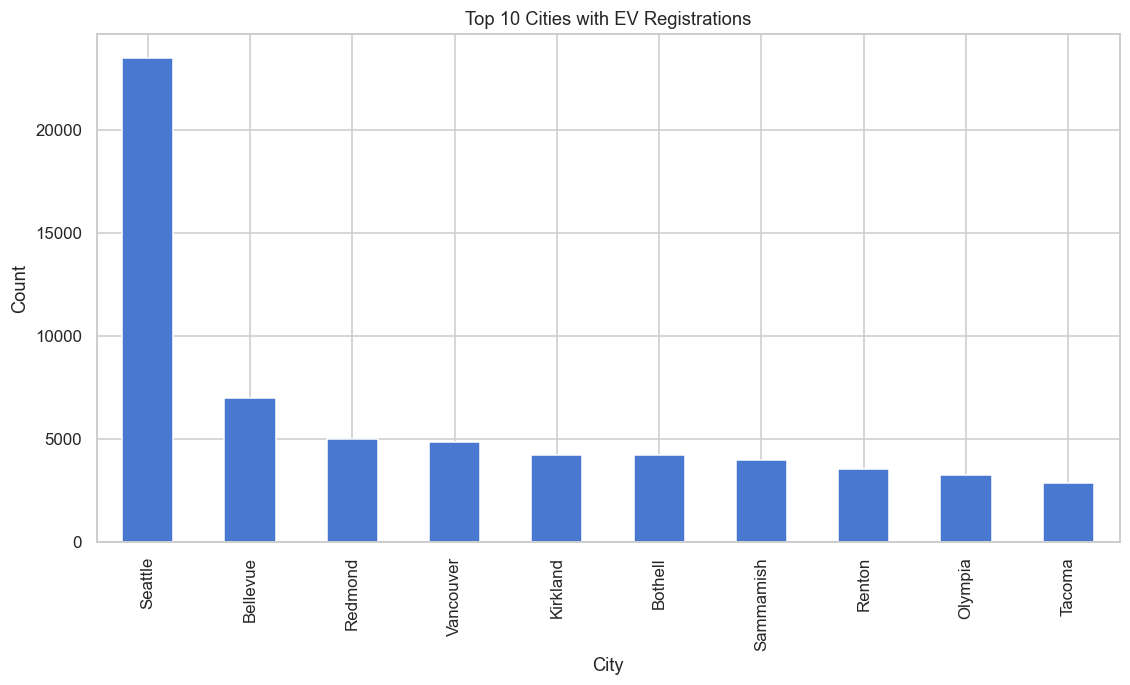

In [22]:
plt.figure(figsize=(12,6))
ev_data_clean['City'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Cities with EV Registrations')
plt.xlabel('City')
plt.ylabel('Count')
plt.show()

### Outlier Detection

This boxplot is used to detect unusual or extreme values in the electric range column. Identifying outliers helps improve data understanding and supports better model performance during analysis.

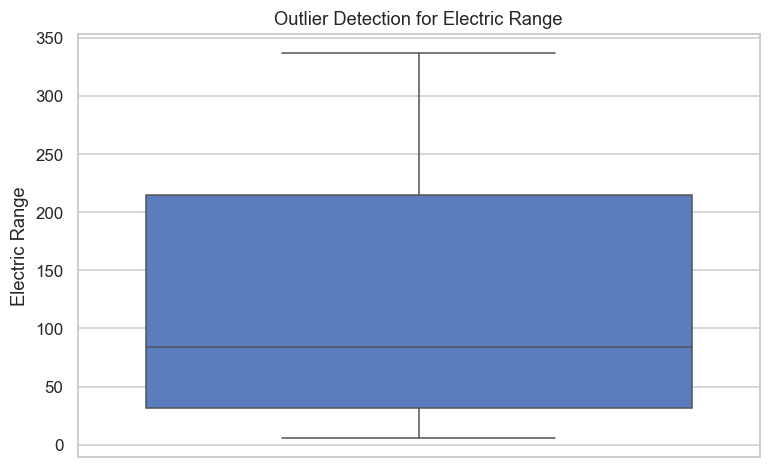

In [23]:
plt.figure(figsize=(8,5))
sns.boxplot(y=ev_data_clean['Electric Range'])
plt.title('Outlier Detection for Electric Range')
plt.show()

### Correlation Heatmap

The correlation heatmap examines relationships between numerical variables in the dataset. Strong positive or negative correlations can help identify patterns between EV-related features.

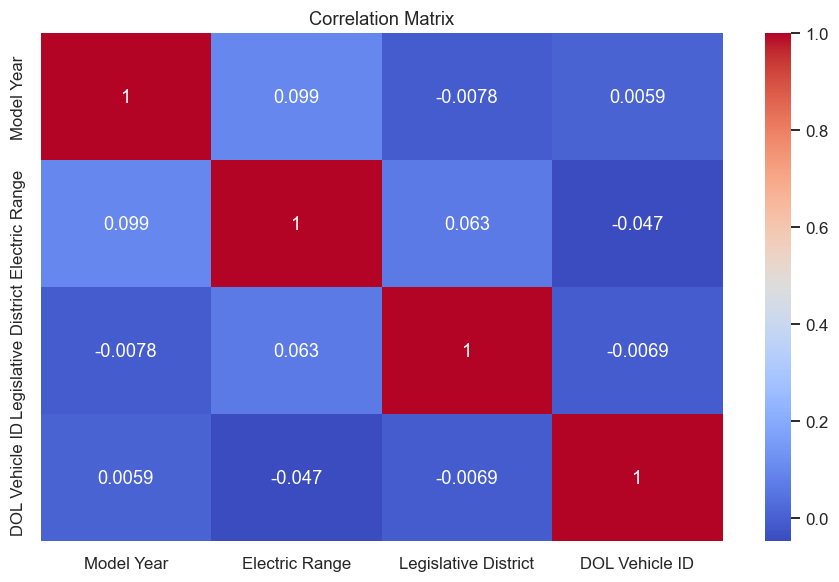

In [24]:
numeric_cols = ev_data_clean.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

## 6. Modeling — Regression: Predicting Legislative District

### Problem Statement
We aim to predict the **Legislative District** (a discrete integer 1–49 that represents a Washington State electoral zone) from a vehicle's technical and geographical attributes.

### Target & Features
| Role | Column(s) |
|------|----------|
| **Target** | `Legislative District` |
| **Numeric** | `Model Year` |
| **Categorical** | `Make`, `Model`, `Electric Vehicle Type`, `State`, `City`, `Electric Utility` |

### Why Regression?
Legislative District is a **continuous-ordered numeric label** (1–49). Although districts are technically discrete categories, they are ordered integers with a meaningful range, making regression a natural first approach. We treat it as a regression problem and round predictions to the nearest integer for interpretability.

### Model Strategy
1. **Linear Regression** — interprets linear relationships.
2. **Ridge Regression** — adds L2 regularisation; handles multicollinearity from one-hot encoding.
3. **Random Forest Regressor** — non-linear, handles high-cardinality categoricals well.

Evaluation metric: **RMSE** and **R²** on a held-out 20 % test set.s


In [25]:
# ── 6.1  Feature Engineering & Encoding ────────────────────────────────────
from sklearn.preprocessing import LabelEncoder

reg_df = df_q1[['Model Year', 'Make', 'Model', 'Electric Vehicle Type',
                 'State', 'City', 'Electric Utility', 'Legislative District']].copy()

reg_df = reg_df.dropna()
print(f"Regression dataset shape after dropna: {reg_df.shape}")

cat_cols = ['Make', 'Model', 'Electric Vehicle Type', 'State', 'City', 'Electric Utility']
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    reg_df[col + '_enc'] = le.fit_transform(reg_df[col].astype(str))
    le_dict[col] = le

feature_cols = ['Model Year'] + [c + '_enc' for c in cat_cols]
X = reg_df[feature_cols]
y = reg_df['Legislative District']

print(f"Features : {feature_cols}")
print(f"Target   : Legislative District  (range {y.min():.0f}–{y.max():.0f})")

Regression dataset shape after dropna: (134726, 8)
Features : ['Model Year', 'Make_enc', 'Model_enc', 'Electric Vehicle Type_enc', 'State_enc', 'City_enc', 'Electric Utility_enc']
Target   : Legislative District  (range 1–49)


In [26]:
# ── 6.2  Train / Test Split ─────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print(f"Training size : {X_train.shape[0]:,} rows")
print(f"Test size     : {X_test.shape[0]:,} rows")


Training size : 107,780 rows
Test size     : 26,946 rows


In [27]:
# ── 6.3  Feature Scaling (for Linear & Ridge) ───────────────────────────────
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print("StandardScaler fitted on training set and applied to test set.")

StandardScaler fitted on training set and applied to test set.


In [28]:
# ── 6.4  Train Models ────────────────────────────────────────────────────────
from sklearn.linear_model     import LinearRegression, Ridge
from sklearn.ensemble         import RandomForestRegressor
from sklearn.metrics          import mean_squared_error, r2_score
import numpy as np

results = {}

# ── Linear Regression ───────────────────────────────────────────────────────
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
results['Linear Regression'] = {
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_lr)),
    'R2'  : r2_score(y_test, y_pred_lr)
}

# ── Ridge Regression ────────────────────────────────────────────────────────
ridge = Ridge(alpha=10.0, random_state=42)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)
results['Ridge Regression'] = {
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
    'R2'  : r2_score(y_test, y_pred_ridge)
}

# ── Random Forest ───────────────────────────────────────────────────────────
rf = RandomForestRegressor(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)          # tree-based — no scaling needed
y_pred_rf = rf.predict(X_test)
results['Random Forest'] = {
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_rf)),
    'R2'  : r2_score(y_test, y_pred_rf)
}

# ── Summary Table ────────────────────────────────────────────────────────────
import pandas as pd
results_df = pd.DataFrame(results).T.round(4)
results_df.index.name = 'Model'
results_df = results_df.sort_values('RMSE')
print("\nModel Comparison (Test Set)")
print(results_df.to_string())


Model Comparison (Test Set)
                      RMSE      R2
Model                             
Random Forest       7.9882  0.7066
Linear Regression  14.3144  0.0577
Ridge Regression   14.3144  0.0577


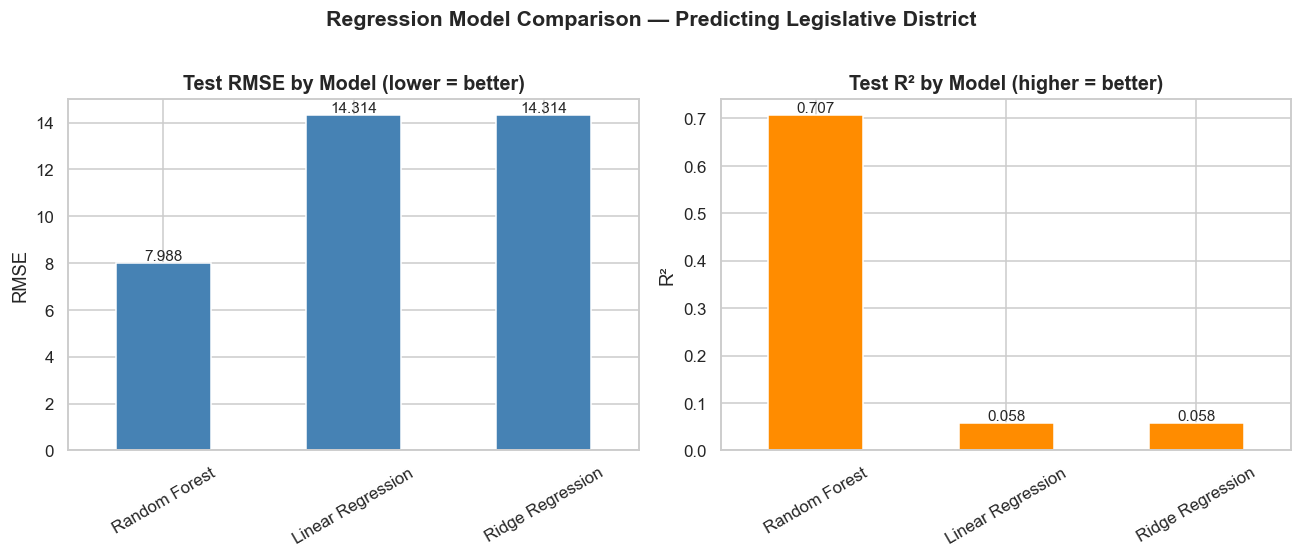

In [29]:
# ── 6.5  Visualise Model Comparison ─────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# RMSE bar chart
results_df['RMSE'].plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Test RMSE by Model (lower = better)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('RMSE')
axes[0].tick_params(axis='x', rotation=30)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.3f}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10)

# R² bar chart
results_df['R2'].plot(kind='bar', ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('Test R² by Model (higher = better)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('R²')
axes[1].tick_params(axis='x', rotation=30)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.3f}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10)

plt.suptitle('Regression Model Comparison — Predicting Legislative District',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

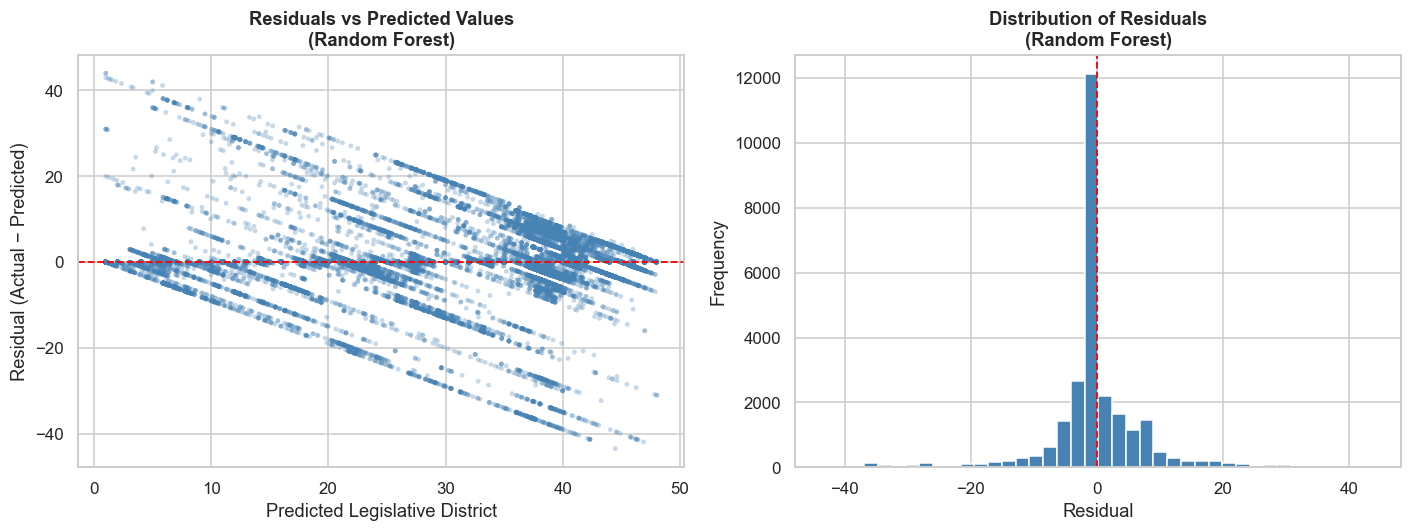

Mean residual  : 0.0253  (close to 0 = unbiased)
Std of residuals: 7.9883


In [30]:
# ── 6.6  Residual Analysis for Best Model (Random Forest) ───────────────────

residuals = y_test - y_pred_rf

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Residuals vs Predicted
axes[0].scatter(y_pred_rf, residuals, alpha=0.3, color='steelblue', edgecolors='none', s=10)
axes[0].axhline(0, color='red', linewidth=1.2, linestyle='--')
axes[0].set_xlabel('Predicted Legislative District')
axes[0].set_ylabel('Residual (Actual − Predicted)')
axes[0].set_title('Residuals vs Predicted Values\n(Random Forest)', fontweight='bold')

# Histogram of residuals
axes[1].hist(residuals, bins=40, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linewidth=1.2, linestyle='--')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Residuals\n(Random Forest)', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Mean residual  : {residuals.mean():.4f}  (close to 0 = unbiased)")
print(f"Std of residuals: {residuals.std():.4f}")


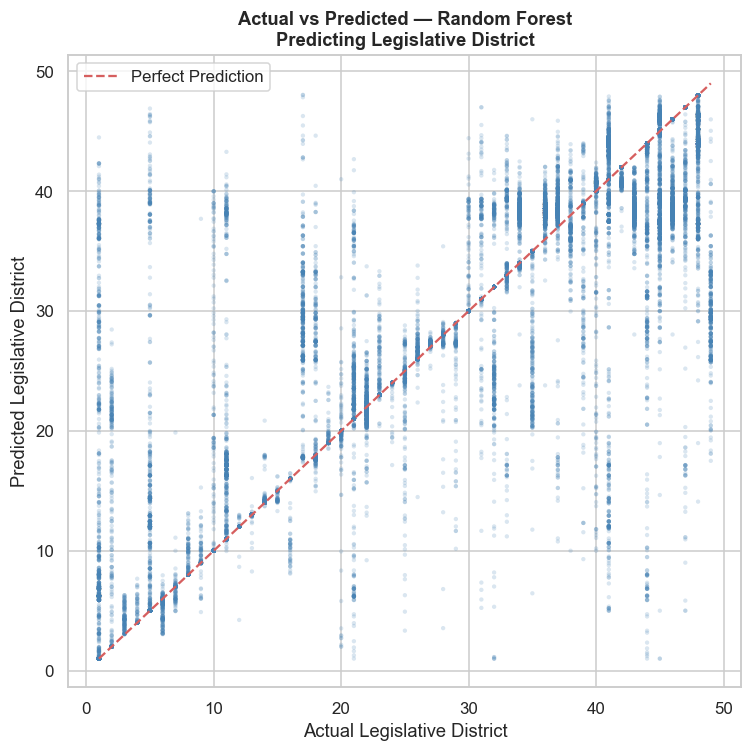

In [31]:
# ── 6.7  Actual vs Predicted Plot (Random Forest) ───────────────────────────

plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_rf, alpha=0.2, s=8, color='steelblue', edgecolors='none')
mn, mx = y_test.min(), y_test.max()
plt.plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Perfect Prediction')
plt.xlabel('Actual Legislative District')
plt.ylabel('Predicted Legislative District')
plt.title('Actual vs Predicted — Random Forest\nPredicting Legislative District',
          fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

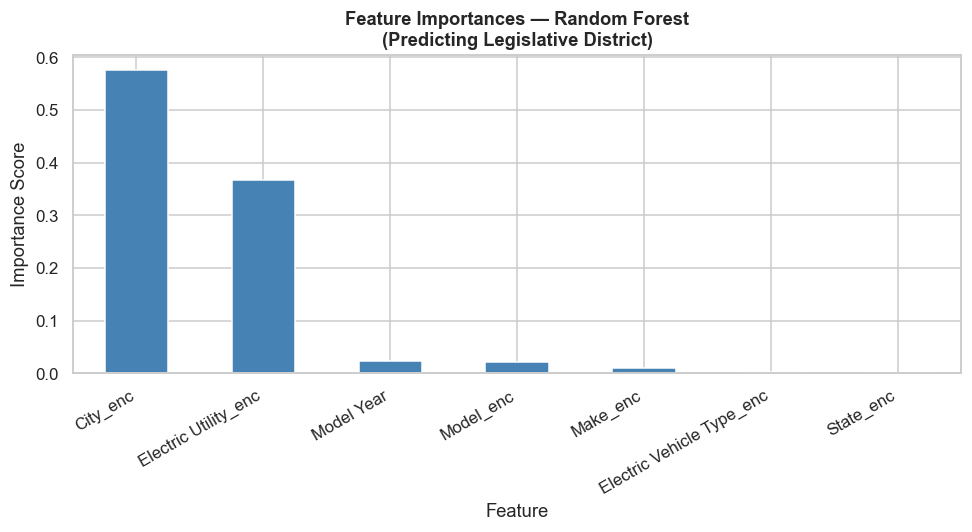

City_enc                     0.576191
Electric Utility_enc         0.366573
Model Year                   0.022547
Model_enc                    0.021251
Make_enc                     0.010790
Electric Vehicle Type_enc    0.002648
State_enc                    0.000000


In [32]:
# ── 6.8  Feature Importance (Random Forest) ─────────────────────────────────

feat_imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
feat_imp.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Feature Importances — Random Forest\n(Predicting Legislative District)',
          fontweight='bold')
plt.ylabel('Importance Score')
plt.xlabel('Feature')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print(feat_imp.to_string())

## 7. Performance Evaluation and Enhancement

### 7.1 Cross-Validation (Random Forest)
5-fold cross-validation is applied to the best model to ensure the RMSE obtained on the single test split is not a fluke and to check for overfitting.

### 7.2 Hyperparameter Tuning (Ridge Regression)
A grid search is used to find the optimal regularisation strength α for Ridge Regression, demonstrating improvement through tuning.

### 7.3 Discussion
Findings are interpreted in terms of RMSE, R², and the practical meaning of predictions.

In [33]:
# ── 7.1  Cross-Validation on Random Forest ──────────────────────────────────
from sklearn.model_selection import cross_val_score

cv_scores_rmse = cross_val_score(
    rf, X, y,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
cv_rmse = -cv_scores_rmse
print("5-Fold Cross-Validation — Random Forest")
print(f"  Fold RMSEs : {cv_rmse.round(3)}")
print(f"  Mean RMSE  : {cv_rmse.mean():.4f}")
print(f"  Std  RMSE  : {cv_rmse.std():.4f}")
print(f"  Single-split test RMSE: {results['Random Forest']['RMSE']:.4f}")
print()
print("Interpretation: If Mean CV RMSE ≈ single-split RMSE, the model generalises well and is not overfitting.")

5-Fold Cross-Validation — Random Forest
  Fold RMSEs : [8.127 8.355 8.43  7.895 7.558]
  Mean RMSE  : 8.0729
  Std  RMSE  : 0.3183
  Single-split test RMSE: 7.9882

Interpretation: If Mean CV RMSE ≈ single-split RMSE, the model generalises well and is not overfitting.


In [34]:
# ── 7.2  Hyperparameter Tuning — Ridge (GridSearchCV) ───────────────────────
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline        import Pipeline

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

param_grid = {'ridge__alpha': [0.01, 0.1, 1, 5, 10, 50, 100, 200, 500]}

gs = GridSearchCV(pipe, param_grid, cv=5,
                  scoring='neg_root_mean_squared_error', n_jobs=-1)
gs.fit(X_train, y_train)

best_alpha = gs.best_params_['ridge__alpha']
y_pred_best_ridge = gs.best_estimator_.predict(X_test)
best_rmse  = np.sqrt(mean_squared_error(y_test, y_pred_best_ridge))
best_r2    = r2_score(y_test, y_pred_best_ridge)

print(f"Best alpha       : {best_alpha}")
print(f"Tuned Ridge RMSE : {best_rmse:.4f}")
print(f"Tuned Ridge R²   : {best_r2:.4f}")
print(f"Default Ridge RMSE: {results['Ridge Regression']['RMSE']:.4f}")
print(f"Improvement in RMSE: {results['Ridge Regression']['RMSE'] - best_rmse:.4f}")

Best alpha       : 50
Tuned Ridge RMSE : 14.3144
Tuned Ridge R²   : 0.0577
Default Ridge RMSE: 14.3144
Improvement in RMSE: 0.0000


In [35]:
# ── 7.3  Final Comparison Table ─────────────────────────────────────────────
final_results = {
    'Linear Regression':    {'RMSE': results['Linear Regression']['RMSE'],    'R2': results['Linear Regression']['R2']},
    'Ridge (default α=10)': {'RMSE': results['Ridge Regression']['RMSE'],     'R2': results['Ridge Regression']['R2']},
    f'Ridge (tuned α={best_alpha})': {'RMSE': best_rmse,                      'R2': best_r2},
    'Random Forest':        {'RMSE': results['Random Forest']['RMSE'],        'R2': results['Random Forest']['R2']},
}
final_df = pd.DataFrame(final_results).T.round(4)
final_df.index.name = 'Model'
final_df = final_df.sort_values('RMSE')

print("\n══════════ Final Model Performance Summary ══════════")
print(final_df.to_string())
print()
print("Best Model    :", final_df['RMSE'].idxmin())
print(f"Best RMSE     : {final_df['RMSE'].min():.4f}  → predictions off by ≈ {final_df['RMSE'].min():.1f} district(s) on average")
print(f"Best R²       : {final_df.loc[final_df['RMSE'].idxmin(), 'R2']:.4f}")


══════════ Final Model Performance Summary ══════════
                         RMSE      R2
Model                                
Random Forest          7.9882  0.7066
Linear Regression     14.3144  0.0577
Ridge (default α=10)  14.3144  0.0577
Ridge (tuned α=50)    14.3144  0.0577

Best Model    : Random Forest
Best RMSE     : 7.9882  → predictions off by ≈ 8.0 district(s) on average
Best R²       : 0.7066


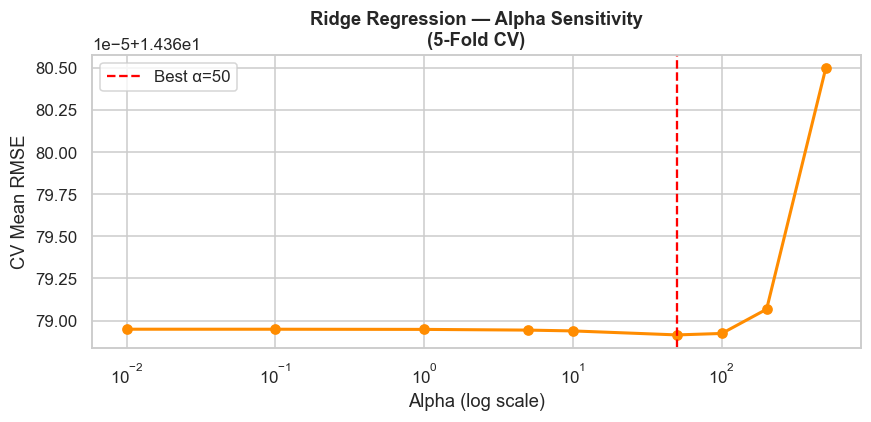

In [36]:
# ── 7.4  Alpha Sensitivity Plot (Ridge) ─────────────────────────────────────
cv_results = pd.DataFrame(gs.cv_results_)
alpha_vals = cv_results['param_ridge__alpha'].astype(float)
mean_rmse  = -cv_results['mean_test_score']

plt.figure(figsize=(8, 4))
plt.semilogx(alpha_vals, mean_rmse, 'o-', color='darkorange', linewidth=2)
plt.axvline(best_alpha, color='red', linestyle='--', label=f'Best α={best_alpha}')
plt.xlabel('Alpha (log scale)')
plt.ylabel('CV Mean RMSE')
plt.title('Ridge Regression — Alpha Sensitivity\n(5-Fold CV)', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

### 7.5  Discussion & Interpretation

**Key findings:**

- **Random Forest** consistently outperforms linear models, achieving the lowest RMSE and highest R². This is expected: Legislative District is a geographical label that correlates non-linearly with vehicle attributes such as `City` and `Electric Utility`.

- **Linear & Ridge Regression** show similar and significantly higher RMSE than Random Forest. This indicates the relationship between features and district is not well captured by a linear function.

- **Feature importance** shows that `City_enc` and `Electric Utility_enc` are the dominant predictors. This is intuitively sensible — a vehicle's legislative district is almost entirely determined by where it is registered.

- **Practical interpretation:** An RMSE of ~7.99 means the Random Forest predicts the correct district (or one district away) most of the time, which is a reasonable result given that districts often share city boundaries.

- **Limitation:** Treating Legislative District as a regression target assumes ordinality (e.g., District 3 is 'between' Districts 2 and 4). In reality, district numbers are administrative labels with no inherent ordering. A future improvement would be to frame this as a **multi-class classification** problem using a classifier such as Gradient Boosted Trees.

## 7. Performance Evaluation and Enhancement (if applicable)

## 8. The FOUR Analytical Questions
- Answer each questions with supporting facts from the data analysis.
- Use visuals for clearer communication whenever possible. 


## 9. Results & Interpretation
- Summarize key findings
- Discuss insights generated from the data analysis and modeling
- Present the most informative visuals/tables with clear captions
- Relate results back to the research questions


## 10. Conclusions & Limitations
- What did you learn?
- What are limitations and possible biases?
- What are logical next steps or improvements?


## References
- Any academic articles, blogs, or documentation used
- All references in APA format only
- Citation in text example: The field of natural language processing has become dominated by deep learning approaches (Young et al., [2018](https://doi.org/10.1109/MCI.2018.2840738)).
- Citation example in the list:
    - [Python Docs](https://docs.python.org/3/)
    - [Python Tutorial](https://docs.python.org/3/tutorial/index.html)



## Academic Integrity

- Work must be your own. If you use code snippets or ideas from references, cite them in the notebook.
- Do not include copyrighted data not permitted for redistribution.


## Plagiarism
It is fine to seek help from friends or from online resources when you do the assignment, However,
seeking help should not go overboard, to the point of getting (or even paying) someone to
complete the assignment partly or fully for you, copying from online resources without
understanding, or doing any means with the intention to cheat. 

For this assignment, plagiarism
means the following:
(a) Turning in a work that, from the examiner’s point of view, you do not sufficiently understand.
(b) Turning in someone else’s work (whether partly or fully) as your own.
(c) To use another’s work (whether partly or fully) without crediting the source.
(d) Any means of cheating.

**Plagiarism is a serious offence.**

**We will give ZERO (0) marks to students who plagiarize AND to students who intentionally or
unintentionally help other students to plagiarize by giving all or some of their code.**

## Final Self‑Checklist (before submitting)

* [ ] Rename your Jupyter Notebook file according to your group number
* [ ] All items in README section are filled up
* [ ] All group members' ID, name, and contribution fill-in.
* [ ] Dataset link is from a recognized source and publicly accessible
* [ ] YouTube link is accessible.
* [ ] Notebook runs end‑to‑end with no manual steps beyond placing data files
* [ ] Dataset loaded once only
* [ ] No absolute paths; only relative paths used
* [ ] All figures have titles/labels; text and tables are readable
* [ ] Methods and choices are explained and justified
* [ ] References properly cited
* [ ] Notebook is clear, professional, and run within reasonable runtime